Dataset 0: make_blobs
Covariance matrix (computed):
[[24.07592299 -5.68914278]
 [-5.68914278 42.82257215]]

Eigenvalues (sorted):
[44.41398921 22.48450592]

PC1 axis: [ 0.269 -0.963]
PC2 axis: [-0.963 -0.269]


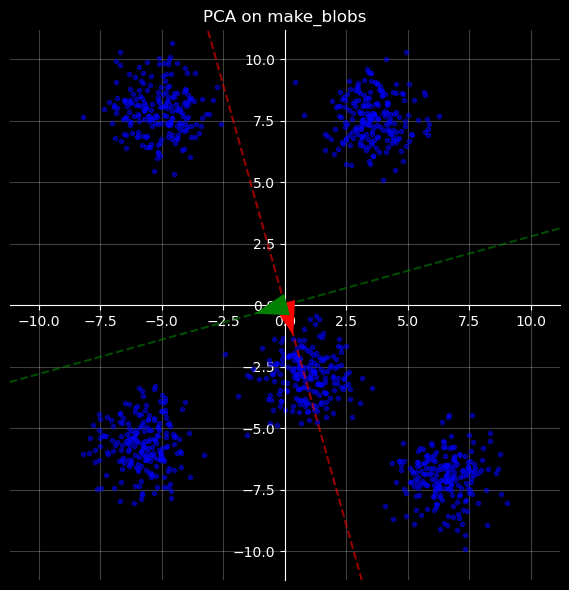

Dataset 1: make_classification
Covariance matrix (computed):
[[1.47491191 0.52078609]
 [0.52078609 1.69583847]]

Eigenvalues (sorted):
[2.11774751 1.05300287]

PC1 axis: [-0.629 -0.777]
PC2 axis: [-0.777  0.629]


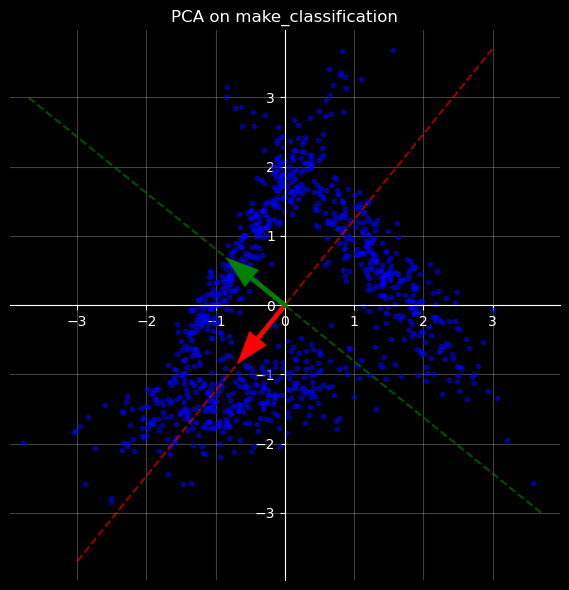

Dataset 2: make_moons
Covariance matrix (computed):
[[ 0.75375251 -0.19092873]
 [-0.19092873  0.24629214]]

Eigenvalues (sorted):
[0.81756411 0.18248054]

PC1 axis: [ 0.948 -0.317]
PC2 axis: [0.317 0.948]


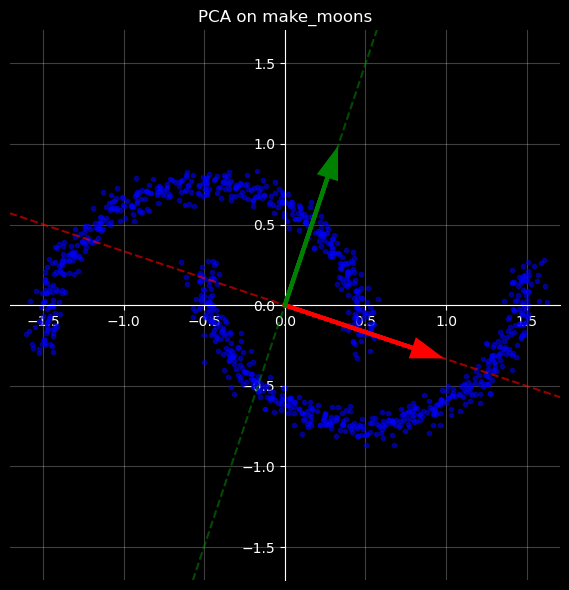

Dataset 3: make_circles
Covariance matrix (computed):
[[ 0.31186884 -0.00060375]
 [-0.00060375  0.31499952]]

Eigenvalues (sorted):
[0.31511192 0.31175644]

PC1 axis: [ 0.183 -0.983]
PC2 axis: [-0.983 -0.183]


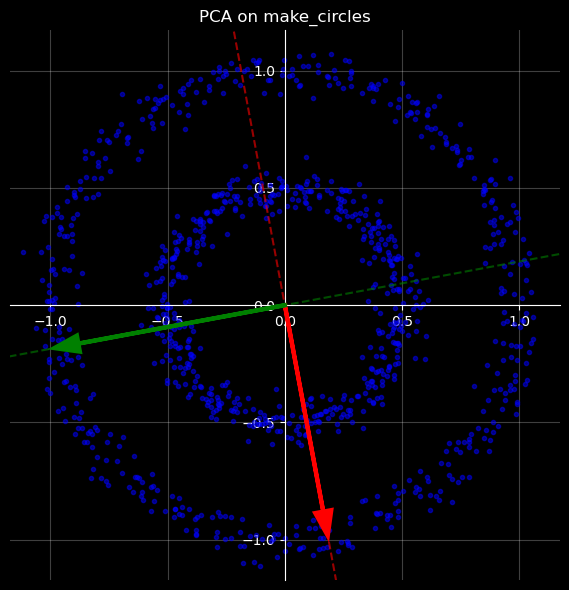

In [5]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy import linalg as LA
from sklearn.datasets import make_classification, make_blobs, make_moons, make_circles
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
plt.style.use("dark_background")

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def center_spines(ax):
    ax.spines["left"].set_position("zero")
    ax.spines["bottom"].set_position("zero")
    ax.spines["right"].set_color("none")
    ax.spines["top"].set_color("none")
    ax.xaxis.set_ticks_position("bottom")
    ax.yaxis.set_ticks_position("left")

def pca_axes_from_X(X):
    """Return eigenvalues/eigenvectors (sorted desc) of cov(X)."""
    cov = np.cov(X.T, bias=False)
    w, v = LA.eig(cov)  # columns of v are eigenvectors
    idx = np.argsort(w)[::-1]
    w = np.real(w[idx])
    v = np.real(v[:, idx])
    return cov, w, v

def unit(u):
    u = np.asarray(u, dtype=float)
    n = np.linalg.norm(u)
    return u / n if n > 0 else u

def plot_dataset_with_pcs(X, u1, u2, title, lim):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(X[:, 0], X[:, 1], "b.", alpha=0.5)

    center_spines(ax)

    # PC arrows (unit directions)
    for u, color, label in [(u1, "red", "PC1"), (u2, "green", "PC2")]:
        ax.arrow(
            0, 0, u[0], u[1],
            head_width=0.06 * lim,
            length_includes_head=True,
            linewidth=3,
            color=color,
            zorder=5
        )

    # Dashed axis lines along PCs
    L = 1.2 * lim
    for u, color in [(u1, "red"), (u2, "green")]:
        ax.plot(
            [-L*u[0], L*u[0]],
            [-L*u[1], L*u[1]],
            linestyle="--",
            linewidth=1.5,
            color=color,
            alpha=0.6,
            zorder=2
        )

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.grid(True, alpha=0.25)
    ax.set_title(title)

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Dataset generator (exactly as your choices, but looped)
# ------------------------------------------------------------
n_samples = 1000

def get_dataset(choice, n_samples=1000):
    if choice == 0:
        X, y = make_blobs(
            n_samples=n_samples,
            n_features=2,
            centers=5,
            cluster_std=1,
            random_state=10
        )
        name = "make_blobs"
    elif choice == 1:
        X, y = make_classification(
            n_samples=n_samples,
            n_features=2,
            n_informative=2,
            n_redundant=0,
            n_clusters_per_class=1,
            n_classes=3,
            random_state=42
        )
        name = "make_classification"
    elif choice == 2:
        X, y = make_moons(
            n_samples=n_samples,
            noise=0.05,
            random_state=42
        )
        name = "make_moons"
    elif choice == 3:
        X, y = make_circles(
            n_samples=n_samples,
            noise=0.05,
            factor=0.5,
            random_state=42
        )
        name = "make_circles"
    else:
        raise ValueError("choice must be 0,1,2,3")
    return X, y, name

# ------------------------------------------------------------
# Run: repeat prints + plot for each dataset
# ------------------------------------------------------------
for choice in [0, 1, 2, 3]:
    X, y, name = get_dataset(choice, n_samples=n_samples)

    # center like your snippet
    X = X - X.mean(axis=0)
    MAX = np.max(np.abs(X))
    lim = 1.05 * MAX  # padding

    cov, w, v = pca_axes_from_X(X)

    # principal axes (unit)
    u1 = unit(v[:, 0])
    u2 = unit(v[:, 1])

    print("=" * 70)
    print(f"Dataset {choice}: {name}")
    print("Covariance matrix (computed):")
    print(cov)
    print()
    print("Eigenvalues (sorted):")
    print(w)
    print()
    print("PC1 axis:", np.round(v[:, 0], 3))
    print("PC2 axis:", np.round(v[:, 1], 3))

    plot_dataset_with_pcs(
        X, u1, u2,
        title=f"PCA on {name}",
        lim=lim
    )